# SHAP Explainability — Crane Risk Model

This notebook explains the stored XGBoost crane-risk model using SHAP values.

The goal is to verify whether the model relies on meaningful construction-weather signals such as wind speed, wind gusts, wind trend, and city-specific weather patterns.

Outputs are saved to `reports/figures/`:

- `shap_feature_importance.csv`
- `shap_summary_bar.png`
- `shap_summary_beeswarm.png`
- `shap_dependence_*.png`
- `shap_model_metrics.json`


In [1]:
# Environment setup
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import glob
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)

import shap

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
MODEL_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Figures dir :', FIGURES_DIR)


Project root: c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project
Figures dir : c:\Users\user\Documents\IronHack_Labs\construction-weather-risk-planner_demo_project\reports\figures


## 1. Load Historical Data

The analysis uses the historical raw CSV files from all supported cities. The same feature logic used by the modeling notebook is recreated here so the saved model can be explained independently.

In [2]:
# Load historical CSV files
historical_files = sorted((DATA_DIR / 'raw').glob('*_historical.csv'))
assert historical_files, 'No historical CSV files found in data/raw/'

df_hist = pd.concat([pd.read_csv(f) for f in historical_files], ignore_index=True)
df_hist['date'] = pd.to_datetime(df_hist['date'])

print('Historical rows:', df_hist.shape[0])
print('Date range     :', df_hist['date'].min(), '→', df_hist['date'].max())
print('Cities         :', sorted(df_hist['city'].unique()))
df_hist.head()


Historical rows: 7308
Date range     : 2021-05-30 20:00:00 → 2026-05-30 20:00:00
Cities         : ['Baku', 'Ganja', 'Nakhchivan', 'Shusha']


,date,city,weathercode,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,precipitation_hours,rain_sum,snowfall_sum,windspeed_10m_max,windgusts_10m_max,winddirection_10m_dominant
0,2021-05-30 20:00:00,Baku,0.0,25.4,18.00,25.208456,16.592216,0.0,0.0,0.0,0.0,32.919827,56.519997,352.51193
1,2021-05-31 20:00:00,Baku,3.0,26.4,16.90,25.943666,18.608257,0.0,0.0,0.0,0.0,29.215502,55.440000,186.97010
2,2021-06-01 20:00:00,Baku,2.0,28.4,18.60,30.079884,19.496040,0.0,0.0,0.0,0.0,34.245445,59.039997,201.31120
3,2021-06-02 20:00:00,Baku,0.0,23.0,17.35,21.264378,14.459032,0.0,0.0,0.0,0.0,35.864742,65.159996,347.04218
4,2021-06-03 20:00:00,Baku,1.0,24.9,18.20,24.562061,15.266216,0.0,0.0,0.0,0.0,27.684914,48.960000,356.77255


## 2. Target Definition

The stored crane model was trained to detect days with elevated wind-related crane risk. This notebook uses the current prototype label logic for evaluation and explainability.

In [3]:
# Conservative crane-risk label used for prototype evaluation
CRANE_THRESHOLD_KMH = 30

df_hist['crane_risk'] = (df_hist['windspeed_10m_max'] > CRANE_THRESHOLD_KMH).astype(int)

print('Crane positive rate:', round(df_hist['crane_risk'].mean() * 100, 2), '%')


Crane positive rate: 8.68 %


## 3. Recreate Feature Engineering

These features match the saved `feature_list.pkl` artifact. The focus is on wind behavior, gust instability, recent trend, and city effects.

In [4]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['month'] = pd.to_datetime(df['date']).dt.month

    df['temp_range'] = df['temperature_2m_max'] - df['temperature_2m_min']
    df['wind_power'] = df['windgusts_10m_max'] * df['windspeed_10m_max']
    df['rain_intensity'] = df['precipitation_sum'] / (df['precipitation_hours'] + 1)
    df['wind_ratio'] = df['windgusts_10m_max'] / (df['windspeed_10m_max'] + 1)

    df = df.sort_values(['city', 'date'])

    df['wind_lag1'] = df.groupby('city')['windspeed_10m_max'].shift(1)
    df['wind_lag2'] = df.groupby('city')['windspeed_10m_max'].shift(2)
    df['wind_roll3'] = (
        df.groupby('city')['windspeed_10m_max']
          .rolling(3)
          .mean()
          .reset_index(level=0, drop=True)
    )
    df['gust_lag1'] = df.groupby('city')['windgusts_10m_max'].shift(1)
    df['wind_delta'] = df['windspeed_10m_max'] - df['wind_lag1']

    fill_cols = ['wind_lag1', 'wind_lag2', 'wind_roll3', 'gust_lag1', 'wind_delta']
    df[fill_cols] = df[fill_cols].fillna(0)

    return df


def prepare_features(df: pd.DataFrame, reference_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = engineer_features(df)
    df = pd.get_dummies(df, columns=['city'], drop_first=True)

    base_features = [
        'temperature_2m_max',
        'temperature_2m_min',
        'apparent_temperature_max',
        'windspeed_10m_max',
        'windgusts_10m_max',
        'precipitation_sum',
        'temp_range',
        'wind_power',
        'rain_intensity',
        'wind_ratio',
        'month',
        'wind_lag1',
        'wind_lag2',
        'wind_roll3',
        'gust_lag1',
        'wind_delta',
    ]

    feature_cols = [c for c in base_features if c in df.columns]
    feature_cols += [c for c in df.columns if c.startswith('city_')]

    X = df[feature_cols].copy()

    for col in reference_cols:
        if col not in X.columns:
            X[col] = 0

    X = X[reference_cols].fillna(0)
    return df, X


## 4. Load Saved Model Artifacts

In [5]:
with open(MODEL_DIR / 'feature_list.pkl', 'rb') as f:
    FEATURE_LIST = pickle.load(f)

with open(MODEL_DIR / 'crane_xgb_calibrated.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open(MODEL_DIR / 'thresholds.pkl', 'rb') as f:
    thresholds = pickle.load(f)

XGB_THRESHOLD = thresholds.get('xgb', 0.5)

print('Feature count:', len(FEATURE_LIST))
print('Decision threshold:', round(XGB_THRESHOLD, 4))
print('Model:', type(xgb_model))


Feature count: 19
Decision threshold: 0.6115
Model: <class 'xgboost.sklearn.XGBClassifier'>


## 5. Temporal Train/Test Split

The split preserves time order. This avoids leakage from future weather records into earlier training records.

In [6]:
df_hist = df_hist.sort_values('date').reset_index(drop=True)
split_idx = int(len(df_hist) * 0.8)

df_train = df_hist.iloc[:split_idx].copy()
df_test = df_hist.iloc[split_idx:].copy()

df_train_enc, X_train = prepare_features(df_train, FEATURE_LIST)
df_test_enc, X_test = prepare_features(df_test, FEATURE_LIST)

y_train = df_train_enc['crane_risk'].values
y_test = df_test_enc['crane_risk'].values

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('Train positive rate:', round(y_train.mean() * 100, 2), '%')
print('Test positive rate :', round(y_test.mean() * 100, 2), '%')


X_train: (5846, 19)
X_test : (1462, 19)
Train positive rate: 9.82 %
Test positive rate : 4.1 %


## 6. Model Performance Snapshot

These metrics are included so SHAP explanations are interpreted together with model quality. SHAP explains model behavior; it does not prove that the model is perfect.

In [7]:
test_prob = xgb_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= XGB_THRESHOLD).astype(int)

metrics = {
    'threshold': float(XGB_THRESHOLD),
    'test_rows': int(len(X_test)),
    'test_positive_rate': float(y_test.mean()),
    'test_f1': float(f1_score(y_test, test_pred, zero_division=0)),
    'test_precision': float(precision_score(y_test, test_pred, zero_division=0)),
    'test_recall': float(recall_score(y_test, test_pred, zero_division=0)),
    'test_auc': float(roc_auc_score(y_test, test_prob)),
    'test_average_precision': float(average_precision_score(y_test, test_prob)),
    'confusion_matrix': confusion_matrix(y_test, test_pred).tolist(),
}

with open(FIGURES_DIR / 'shap_model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

pd.DataFrame([metrics])


,threshold,test_rows,test_positive_rate,test_f1,test_precision,test_recall,test_auc,test_average_precision,confusion_matrix
0,0.611455,1462,0.04104,0.0,0.0,0.0,0.40088,0.032662,"[[1339, 63], [60, 0]]"


## 7. SHAP Global Explanation

The global SHAP importance chart ranks features by mean absolute SHAP value. Larger values mean the feature has stronger average influence on the model output.

In [8]:
# Use a sample for faster explanation if needed
X_explain = X_test.copy()
if len(X_explain) > 1000:
    X_explain = X_explain.sample(1000, random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_explain)

if isinstance(shap_values, list):
    shap_arr = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_arr = shap_values

mean_abs = np.abs(shap_arr).mean(axis=0)
importance = (
    pd.DataFrame({'feature': X_explain.columns, 'mean_abs_shap': mean_abs})
      .sort_values('mean_abs_shap', ascending=False)
      .reset_index(drop=True)
)
importance.insert(0, 'rank', np.arange(1, len(importance) + 1))
importance.to_csv(FIGURES_DIR / 'shap_feature_importance.csv', index=False)
importance.head(15)


,rank,feature,mean_abs_shap
0,1,wind_ratio,0.302661
1,2,city_Nakhchivan,0.176353
2,3,wind_lag2,0.163771
3,4,wind_delta,0.153060
4,5,temp_range,0.138022
5,6,wind_lag1,0.137896
6,7,gust_lag1,0.129733
7,8,temperature_2m_min,0.127724
8,9,windspeed_10m_max,0.116893
9,10,wind_roll3,0.111583


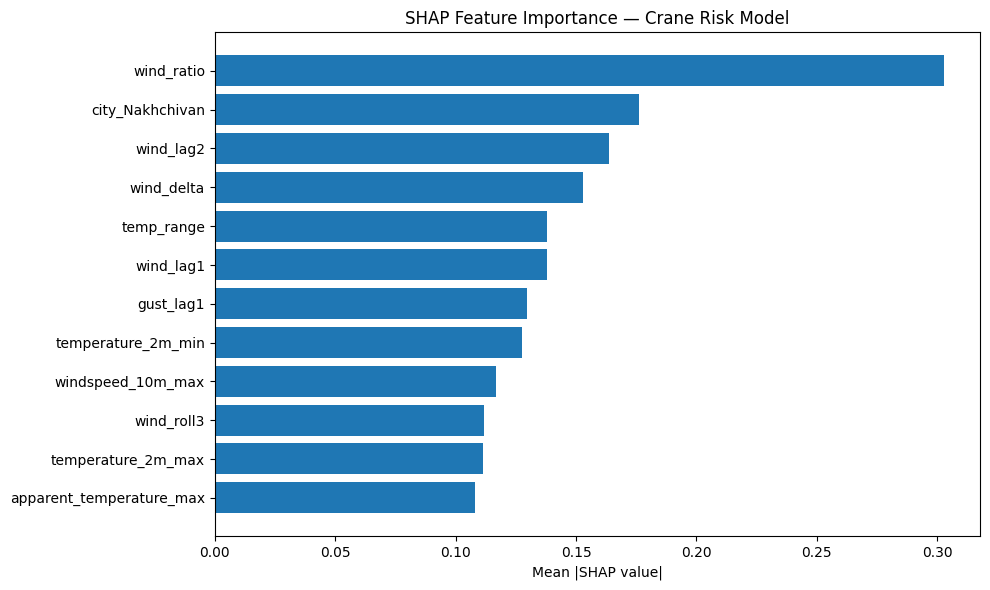

In [9]:
# Bar plot
plt.figure(figsize=(10, 6))
top = importance.head(12).iloc[::-1]
plt.barh(top['feature'], top['mean_abs_shap'])
plt.title('SHAP Feature Importance — Crane Risk Model')
plt.xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary_bar.png', dpi=160, bbox_inches='tight')
plt.show()


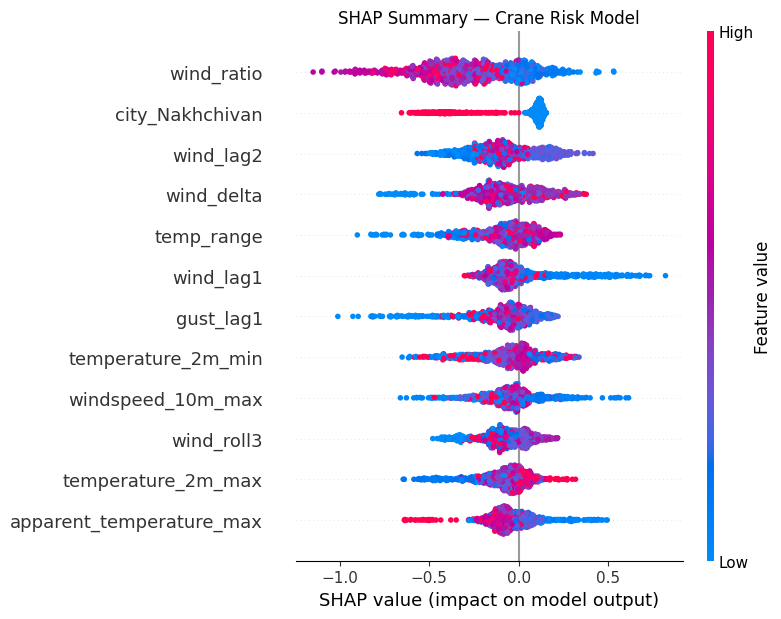

In [10]:
# Beeswarm plot
plt.figure()
shap.summary_plot(shap_arr, X_explain, show=False, max_display=12)
plt.title('SHAP Summary — Crane Risk Model')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_summary_beeswarm.png', dpi=160, bbox_inches='tight')
plt.show()


## 8. SHAP Dependence Plots

Dependence plots show how a feature value changes its contribution to the prediction.

<Figure size 640x480 with 0 Axes>

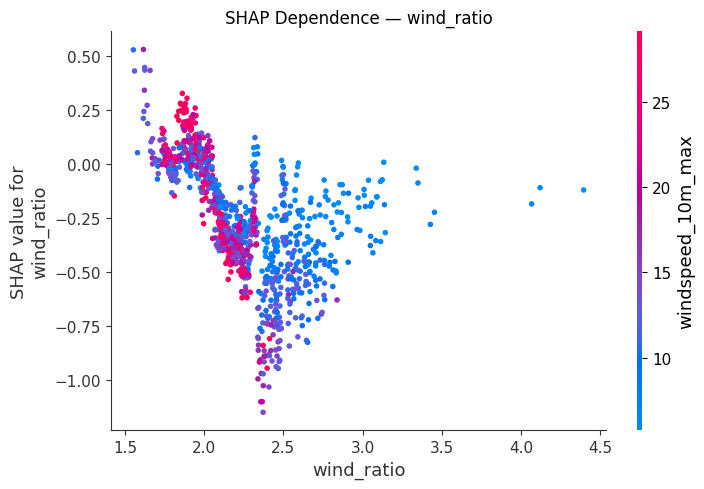

<Figure size 640x480 with 0 Axes>

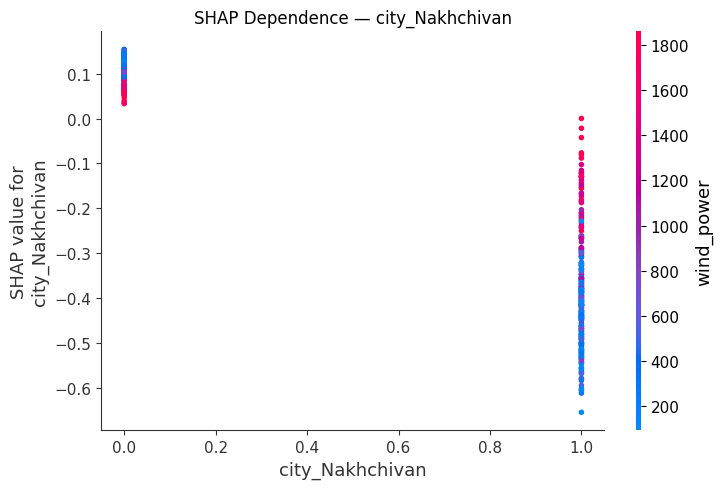

<Figure size 640x480 with 0 Axes>

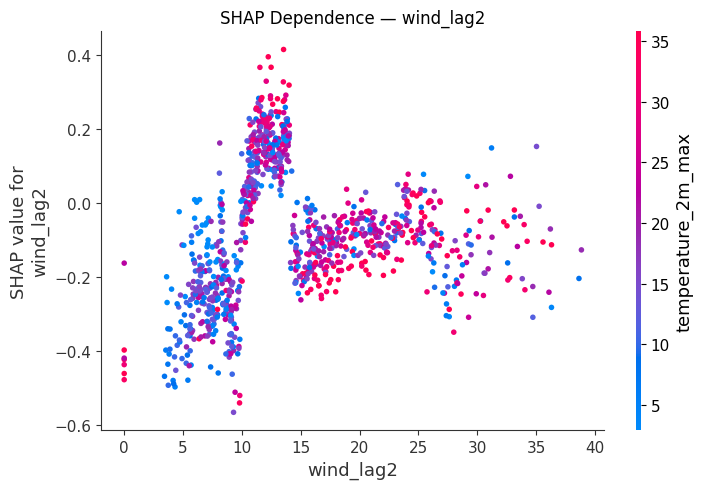

In [11]:
for feature in importance.head(3)['feature']:
    plt.figure()
    shap.dependence_plot(feature, shap_arr, X_explain, show=False)
    plt.title(f'SHAP Dependence — {feature}')
    plt.tight_layout()
    safe_name = feature.replace('/', '_').replace(' ', '_')
    plt.savefig(FIGURES_DIR / f'shap_dependence_{safe_name}.png', dpi=160, bbox_inches='tight')
    plt.show()


## 9. Interpretation Notes

Use these points when explaining the model:

- SHAP confirms whether the model uses wind-related signals such as `wind_ratio`, lagged wind, wind trend, and wind speed.
- If city features rank highly, the model may be learning location-specific climate patterns. This is useful, but it should be monitored to avoid over-reliance on city identity.
- SHAP explains model decisions, but final model quality must still be judged by temporal test-set performance.
- For a safety-oriented system, recall and false negatives are more important than raw accuracy.
